In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

In [13]:
DATA_PATH = Path(r"C:\Users\grand\Music\Code\Ecommerce")

customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
category_translation = pd.read_csv(
    DATA_PATH / "product_category_name_translation.csv"
)

In [14]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "sellers": sellers,
    "products": products,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("Rows:", len(df))
    print("Columns:", len(df.columns))
    print("Missing values:", df.isna().sum().sum())
    print("Duplicates:", df.duplicated().sum())


CUSTOMERS
Rows: 99441
Columns: 5
Missing values: 0
Duplicates: 0

ORDERS
Rows: 99441
Columns: 8
Missing values: 4908
Duplicates: 0

ORDER_ITEMS
Rows: 112650
Columns: 7
Missing values: 0
Duplicates: 0

PAYMENTS
Rows: 103886
Columns: 5
Missing values: 0
Duplicates: 0

REVIEWS
Rows: 99224
Columns: 5
Missing values: 0
Duplicates: 0

SELLERS
Rows: 3095
Columns: 4
Missing values: 0
Duplicates: 0

PRODUCTS
Rows: 32951
Columns: 9
Missing values: 2448
Duplicates: 0

CATEGORY_TRANSLATION
Rows: 71
Columns: 2
Missing values: 0
Duplicates: 0


In [15]:
print(orders.isna().sum()[lambda s: s > 0])

order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64


In [16]:
missing_by_status = (
    orders[orders.isna().any(axis=1)]["order_status"].value_counts()
)
print(missing_by_status)

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered        23
created           5
approved          2
Name: count, dtype: int64


In [17]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [18]:
order_sales = (
    order_items
    .groupby("order_id")
    .agg(
        item_count=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        product_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

order_sales["order_value"] = (
    order_sales["product_value"] +
    order_sales["freight_value"]
)

In [19]:
customer_info = customers[
    [
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
]

In [20]:
order_data = (
    orders
    .merge(customer_info, on="customer_id", how="left")
    .merge(order_sales, on="order_id", how="left")
)

In [21]:
order_data["delivery_days"] = (
    order_data["order_delivered_customer_date"]
    - order_data["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [22]:
order_data["delivery_delay_days"] = (
    order_data["order_delivered_customer_date"]
    - order_data["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [23]:
order_data["delivery_status"] = np.where(
    order_data["delivery_delay_days"] > 0,
    "Late",
    "On Time / Early"
)

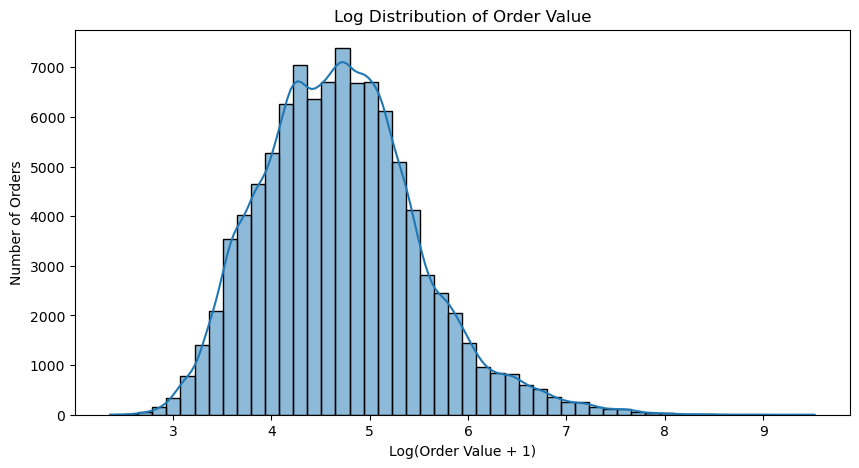

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(order_data["order_value"].dropna()),
    bins=50,
    kde=True
)

plt.title("Log Distribution of Order Value")
plt.xlabel("Log(Order Value + 1)")
plt.ylabel("Number of Orders")

plt.show()

In [26]:
monthly_sales = (
    order_data[
        order_data["order_status"] == "delivered"
    ]
    .assign(
        month=lambda x:
        x["order_purchase_timestamp"].dt.to_period("M")
    )
    .groupby("month")
    .agg(
        revenue=("product_value", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_sales["month"] = monthly_sales["month"].astype(str)

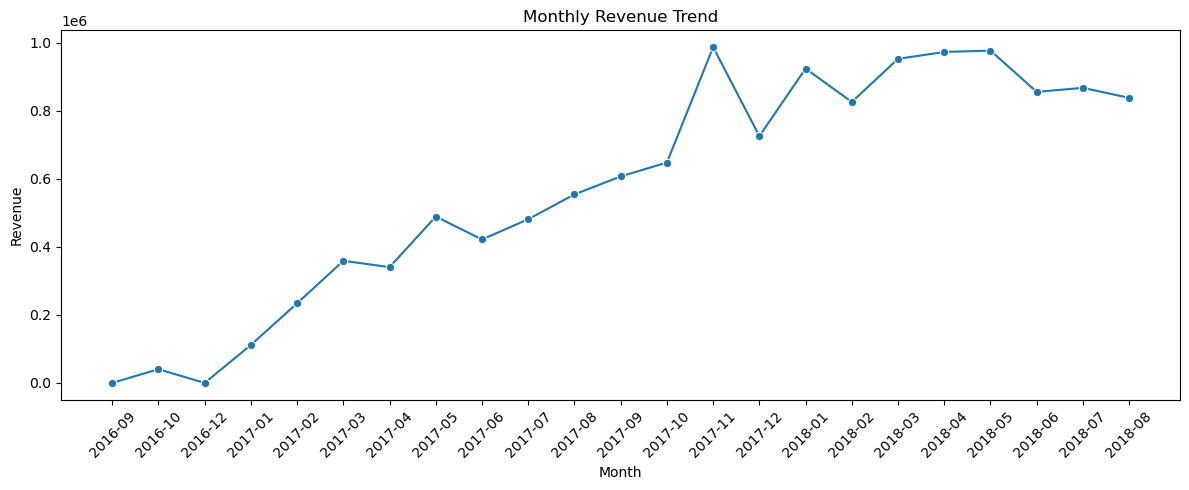

In [27]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="revenue",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [28]:
customer_orders = (
    order_data[
        order_data["order_status"] == "delivered"
    ]
    .groupby("customer_unique_id")
    .agg(
        orders=("order_id", "nunique"),
        total_spend=("order_value", "sum"),
        avg_order_value=("order_value", "mean")
    )
    .reset_index()
)

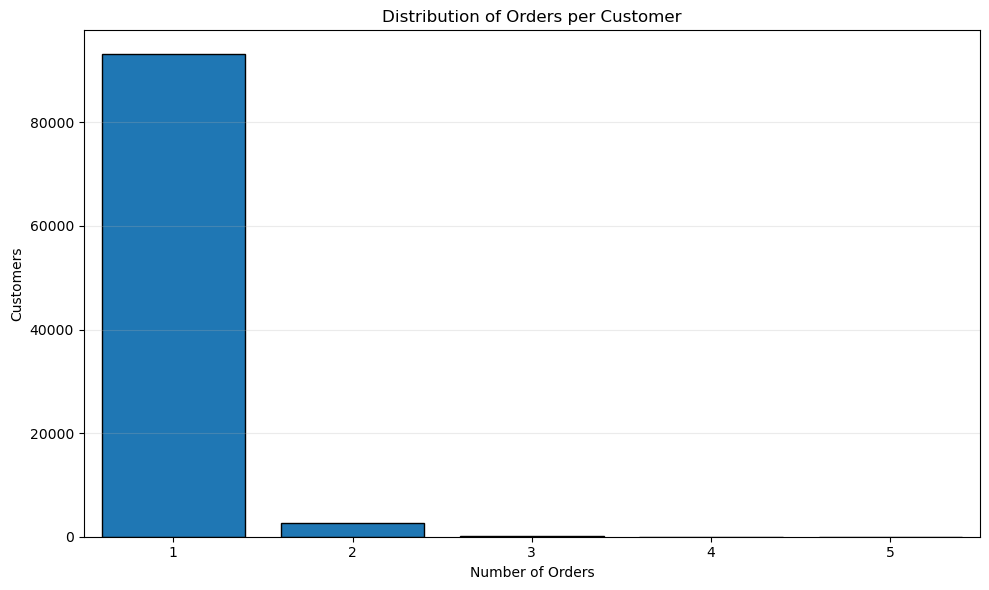

In [82]:
order_customer = orders.merge(
    customers[[
        "customer_id",
        "customer_unique_id"
    ]],
    on="customer_id",
    how="left"
)

customer_order_counts = (
    order_customer
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

counts = customer_order_counts[
    customer_order_counts <= 5
]

plt.figure(figsize=(10, 6))

plt.hist(
    counts,
    bins=np.arange(0.5, 6.5, 1),
    rwidth=0.8,
    edgecolor="black"
)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")

plt.xlim(0.5, 5.5)
plt.xticks(range(1, 6))

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [30]:
repeat_rate = (
    customer_orders["orders"].gt(1).mean() * 100
)

print(f"Repeat customer rate: {repeat_rate:.2f}%")

Repeat customer rate: 3.00%


In [31]:
reference_date = (
    order_data["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

rfm = (
    order_data[
        order_data["order_status"] == "delivered"
    ]
    .groupby("customer_unique_id")
    .agg(
        last_purchase=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("order_value", "sum")
    )
    .reset_index()
)

rfm["recency"] = (
    reference_date - rfm["last_purchase"]
).dt.days

In [32]:
rfm = rfm[
    [
        "customer_unique_id",
        "recency",
        "frequency",
        "monetary"
    ]
]

In [33]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [34]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(int).astype(str) +
    rfm["F_score"].astype(int).astype(str) +
    rfm["M_score"].astype(int).astype(str)
)

In [35]:
delivered = order_data[
    order_data["order_delivered_customer_date"].notna()
].copy()

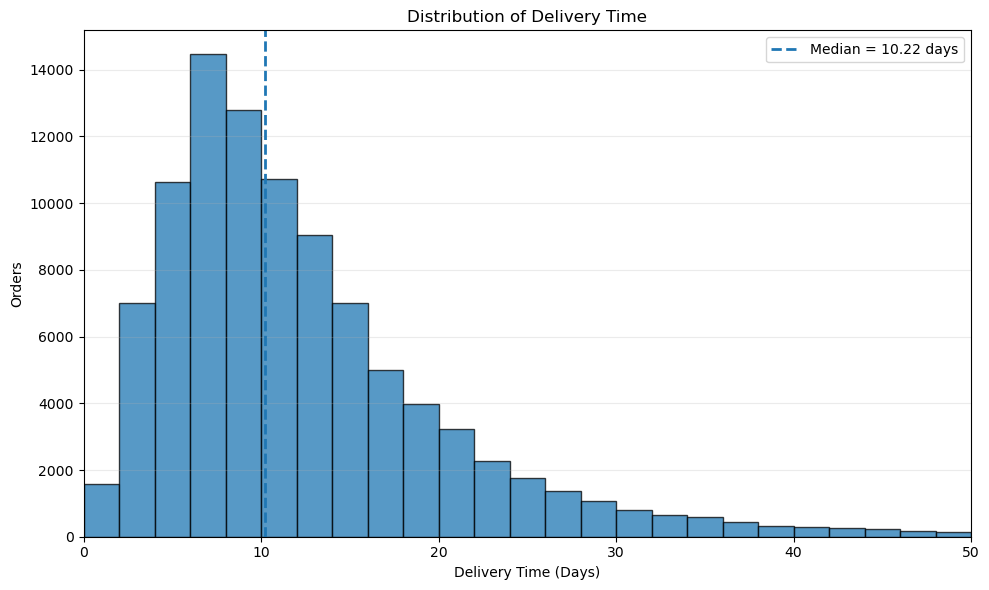

In [74]:
plt.figure(figsize=(10, 6))

delivery_values = delivered["delivery_days"].dropna()

plt.hist(
    delivery_values,
    bins=np.arange(0, 51, 2),
    edgecolor="black",
    alpha=0.75
)

median_delivery = delivery_values.median()

plt.axvline(
    median_delivery,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_delivery:.2f} days"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Orders")

# Zoom into the main distribution
plt.xlim(0, 50)

plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

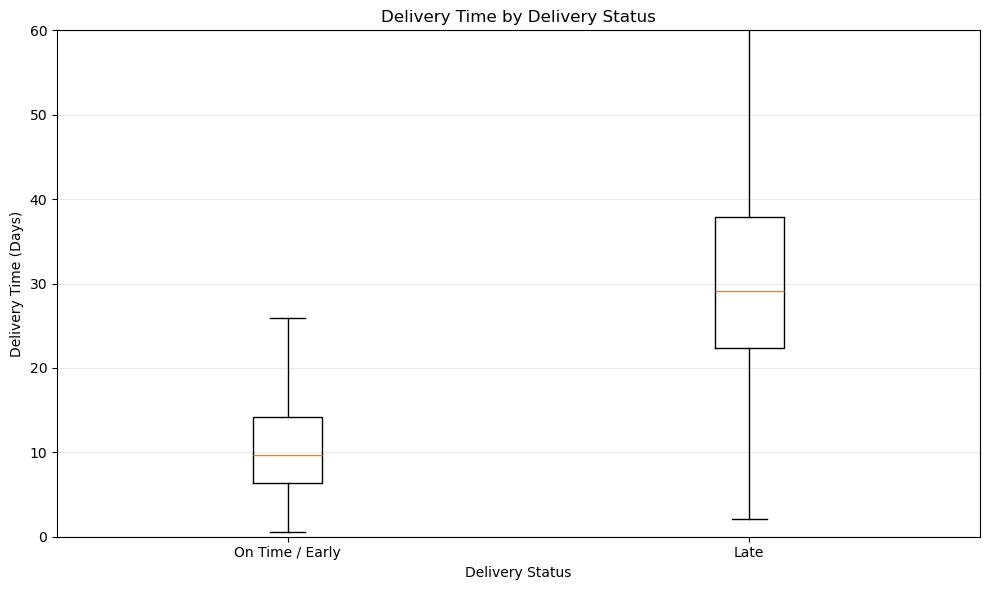

In [73]:
plt.figure(figsize=(10, 6))

groups = [
    delivered.loc[
        delivered["delivery_status"] == "On Time / Early",
        "delivery_days"
    ].dropna(),

    delivered.loc[
        delivered["delivery_status"] == "Late",
        "delivery_days"
    ].dropna()
]

plt.boxplot(
    groups,
    tick_labels=["On Time / Early", "Late"],
    showfliers=False
)

plt.title("Delivery Time by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Delivery Time (Days)")

# Zoom into the main distribution
plt.ylim(0, 60)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [38]:
review_data = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean")
    )
    .reset_index()
)

In [39]:
delivery_reviews = delivered.merge(
    review_data,
    on="order_id",
    how="inner"
)

In [40]:
delivery_reviews.groupby(
    "delivery_status"
)["review_score"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
delivery_status,,,,
Late,7662,2.566562,2.0,1.657714
On Time / Early,88168,4.294151,5.0,1.146214


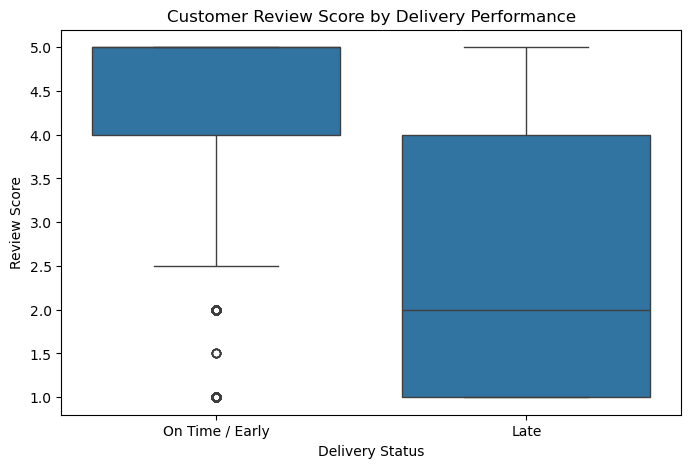

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=delivery_reviews,
    x="delivery_status",
    y="review_score"
)

plt.title("Customer Review Score by Delivery Performance")
plt.xlabel("Delivery Status")
plt.ylabel("Review Score")

plt.show()

In [42]:
late_reviews = delivery_reviews.loc[
    delivery_reviews["delivery_status"] == "Late",
    "review_score"
].dropna()

ontime_reviews = delivery_reviews.loc[
    delivery_reviews["delivery_status"] == "On Time / Early",
    "review_score"
].dropna()

In [43]:
u_stat, p_value = stats.mannwhitneyu(
    late_reviews,
    ontime_reviews,
    alternative="two-sided"
)

print("Mann–Whitney U:", u_stat)
print("p-value:", p_value)

Mann–Whitney U: 150716905.5
p-value: 0.0


In [44]:
alpha = 0.05

if p_value < alpha:
    print(
        "The difference in review-score distributions "
        "is statistically significant."
    )
else:
    print(
        "There is insufficient evidence to conclude "
        "that the distributions differ."
    )

The difference in review-score distributions is statistically significant.


In [45]:
n1 = len(late_reviews)
n2 = len(ontime_reviews)

rank_biserial = (
    1 - (2 * u_stat) / (n1 * n2)
)

print(
    "Rank-biserial correlation:",
    rank_biserial
)

Rank-biserial correlation: 0.5537904846638264


In [46]:
regional_delivery = (
    delivered
    .groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        late_rate=(
            "delivery_delay_days",
            lambda x: (x > 0).mean() * 100
        )
    )
    .reset_index()
)

In [47]:
regional_delivery = regional_delivery[
    regional_delivery["orders"] >= 100
]

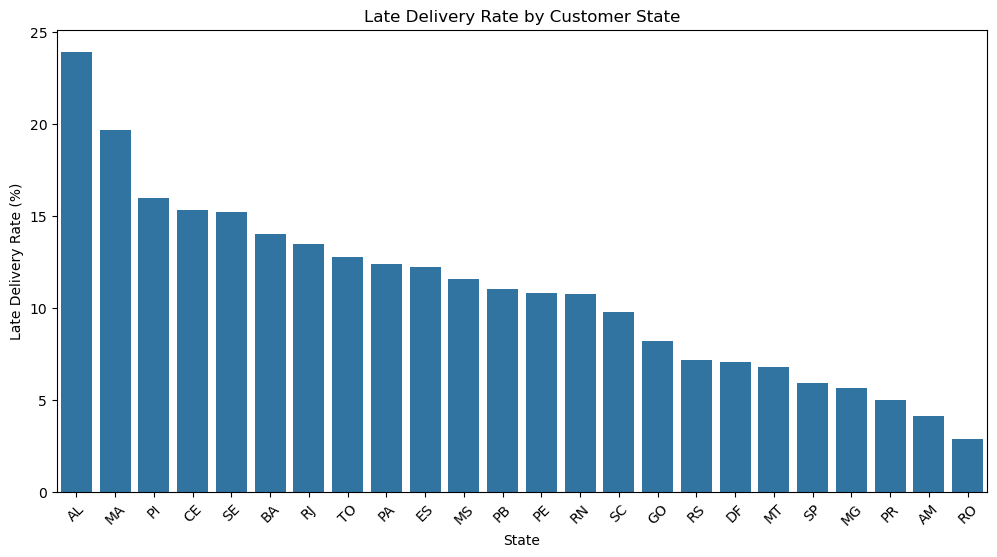

In [48]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=regional_delivery.sort_values(
        "late_rate",
        ascending=False
    ),
    x="customer_state",
    y="late_rate"
)

plt.title("Late Delivery Rate by Customer State")
plt.xlabel("State")
plt.ylabel("Late Delivery Rate (%)")

plt.xticks(rotation=45)
plt.show()

In [49]:
state_groups = [
    group["delivery_days"].dropna()
    for _, group in delivered.groupby("customer_state")
    if len(group) >= 100
]

h_stat, p_value = stats.kruskal(*state_groups)

print("Kruskal-Wallis H:", h_stat)
print("p-value:", p_value)

Kruskal-Wallis H: 23956.47723355599
p-value: 0.0


In [50]:
order_items["freight_ratio"] = (
    order_items["freight_value"] /
    order_items["price"]
) * 100

In [51]:
freight_analysis = order_items[
    order_items["price"] > 0
].copy()

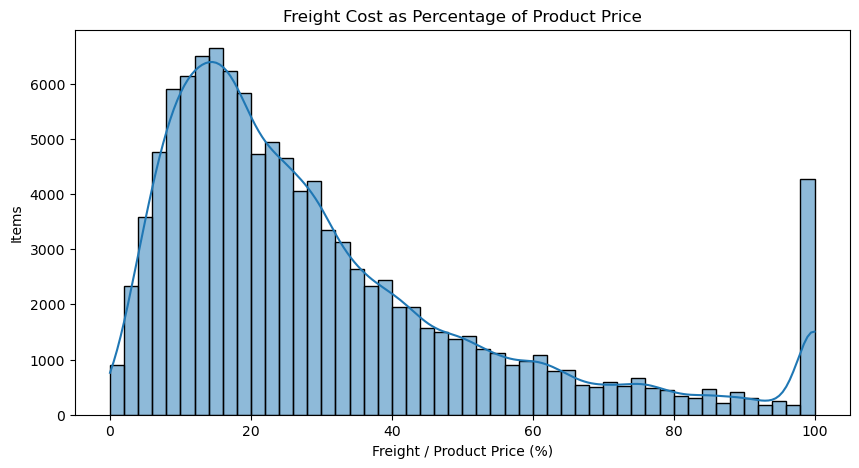

In [52]:
plt.figure(figsize=(10, 5))

sns.histplot(
    freight_analysis["freight_ratio"].clip(upper=100),
    bins=50,
    kde=True
)

plt.title("Freight Cost as Percentage of Product Price")
plt.xlabel("Freight / Product Price (%)")
plt.ylabel("Items")

plt.show()

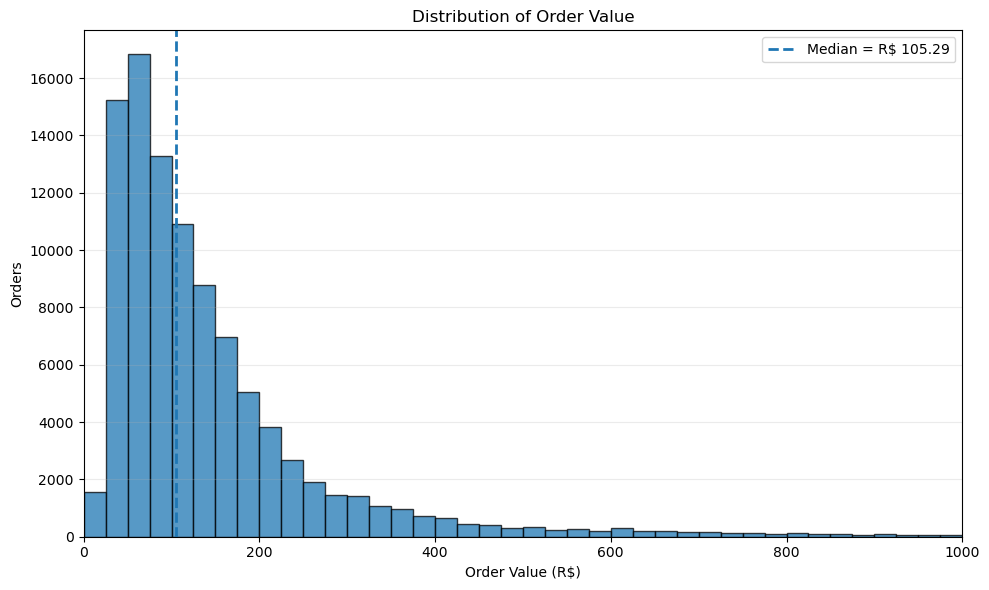

In [80]:
order_value = (
    order_items
    .groupby("order_id")
    .agg(
        product_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
)

order_value["order_value"] = (
    order_value["product_value"] +
    order_value["freight_value"]
)

values = order_value["order_value"].dropna()

# Focus on the main distribution
values_zoom = values[values <= 1000]

plt.figure(figsize=(10, 6))

plt.hist(
    values_zoom,
    bins=np.arange(0, 1001, 25),
    edgecolor="black",
    alpha=0.75
)

median_order_value = values.median()

plt.axvline(
    median_order_value,
    linestyle="--",
    linewidth=2,
    label=f"Median = R$ {median_order_value:.2f}"
)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value (R$)")
plt.ylabel("Orders")

plt.xlim(0, 1000)

plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [53]:
product_freight = (
    order_items
    .merge(
        products,
        on="product_id",
        how="left"
    )
)

In [54]:
product_freight["volume_cm3"] = (
    product_freight["product_length_cm"] *
    product_freight["product_height_cm"] *
    product_freight["product_width_cm"]
)

In [55]:
correlation_columns = [
    "price",
    "freight_value",
    "product_weight_g",
    "volume_cm3"
]

product_freight[
    correlation_columns
].corr(method="spearman")

,price,freight_value,product_weight_g,volume_cm3
price,1.000000,0.434190,0.513985,0.389038
freight_value,0.434190,1.000000,0.446591,0.368587
product_weight_g,0.513985,0.446591,1.000000,0.767701
volume_cm3,0.389038,0.368587,0.767701,1.000000


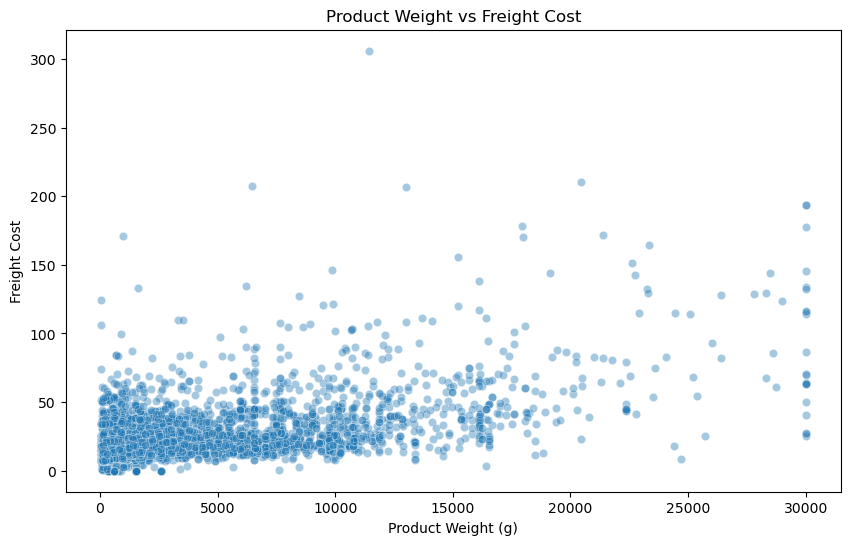

In [56]:
sample = product_freight.sample(
    min(10000, len(product_freight)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample,
    x="product_weight_g",
    y="freight_value",
    alpha=0.4
)

plt.title("Product Weight vs Freight Cost")
plt.xlabel("Product Weight (g)")
plt.ylabel("Freight Cost")

plt.show()

In [57]:
payment_order = (
    payments
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        max_installments=("payment_installments", "max")
    )
    .reset_index()
)

In [58]:
payment_analysis = order_data.merge(
    payment_order,
    on="order_id",
    how="left"
)

In [59]:
installment_summary = (
    payment_analysis[
        payment_analysis["max_installments"].notna()
    ]
    .groupby("max_installments")
    .agg(
        orders=("order_id", "nunique"),
        avg_order_value=("order_value", "mean"),
        median_order_value=("order_value", "median")
    )
    .reset_index()
)

In [60]:
corr, p_value = stats.spearmanr(
    payment_analysis["max_installments"],
    payment_analysis["order_value"],
    nan_policy="omit"
)

print("Spearman correlation:", corr)
print("p-value:", p_value)

Spearman correlation: 0.38177010810888173
p-value: 0.0


In [61]:
products_en = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products_en["category"] = (
    products_en["product_category_name_english"]
    .fillna(products_en["product_category_name"])
)

In [62]:
category_sales = (
    order_items
    .merge(
        products_en[["product_id", "category"]],
        on="product_id",
        how="left"
    )
    .groupby("category")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        items=("product_id", "count")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

In [63]:
total_revenue = category_sales["revenue"].sum()

category_sales["revenue_share"] = (
    category_sales["revenue"] /
    total_revenue
)

In [64]:
top5_share = (
    category_sales
    .head(5)["revenue_share"]
    .sum()
)

print(f"Top 5 category revenue share: {top5_share:.2%}")

Top 5 category revenue share: 40.27%


In [65]:
seller_sales = (
    order_items
    .groupby("seller_id")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

seller_sales["revenue_share"] = (
    seller_sales["revenue"] /
    seller_sales["revenue"].sum()
)

In [66]:
seller_hhi = (
    seller_sales["revenue_share"]
    .pow(2)
    .sum()
)

print("Seller Revenue HHI:", seller_hhi)

Seller Revenue HHI: 0.0035693328516744143


In [67]:
top10_seller_share = (
    seller_sales
    .nlargest(10, "revenue")["revenue_share"]
    .sum()
)

print(
    f"Top 10 seller revenue share: "
    f"{top10_seller_share:.2%}"
)

Top 10 seller revenue share: 13.15%


In [68]:
Q1 = order_data["order_value"].quantile(0.25)
Q3 = order_data["order_value"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = order_data[
    (order_data["order_value"] < lower_bound) |
    (order_data["order_value"] > upper_bound)
]

print("Number of order-value outliers:", len(outliers))

Number of order-value outliers: 7775


In [69]:
outliers[
    [
        "order_id",
        "customer_state",
        "order_value",
        "product_value",
        "freight_value"
    ]
].sort_values(
    "order_value",
    ascending=False
).head(20)

,order_id,customer_state,order_value,product_value,freight_value
13390,03caa2c082116e1d31e67e9ae3700499,RJ,13664.08,13440.00,224.08
66599,736e1922ae60d0d6a89247b851902527,ES,7274.88,7160.00,114.88
22171,0812eb902a67711a1cb742b3cdaa65ae,MS,6929.31,6735.00,194.31
28326,fefacc66af859508bf1a7934eab1e97f,ES,6922.21,6729.00,193.21
3508,f5136e38d1a14a4dbd87dff67da82701,SP,6726.66,6499.00,227.66
32322,2cc9089445046817a7539d90805e6e5a,MG,6081.54,5934.60,146.94
53352,a96610ab360d42a2e5335a3998b4718a,RJ,4950.34,4799.00,151.34
41086,b4c4b76c642808cbe472a32b86cddc95,GO,4809.44,4599.90,209.54
40327,199af31afc78c699f0dbf71fb178d4d4,SP,4764.34,4690.00,74.34
40342,8dbc85d1447242f3b127dda390d56e19,PB,4681.78,4590.00,91.78


In [72]:
statistical_results = pd.DataFrame({
    "Analysis": [
        "Late vs On-time Review Score",
        "Regional Delivery Time",
        "Installments vs Order Value"
    ],
    "Test": [
        "Mann-Whitney U",
        "Kruskal-Wallis",
        "Spearman Correlation"
    ],
    "Statistic": [
        u_stat,
        h_stat,
        corr
    ],
    "p_value": [
        p_value,       # replace with separate stored values
        p_value,       # replace with separate stored values
        p_value        # replace with separate stored values
    ]
})

statistical_results

,Analysis,Test,Statistic,p_value
0,Late vs On-time Review Score,Mann-Whitney U,1.507169e+08,0.0
1,Regional Delivery Time,Kruskal-Wallis,2.395648e+04,0.0
2,Installments vs Order Value,Spearman Correlation,3.817701e-01,0.0
